<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/Decision_Tree_Classification_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Experiment 6: Decision Tree Classification
Dataset: Iris dataset (real-world, classic 150-row dataset)

- Classifies iris species using a Decision Tree
- Splits into training and testing sets
- Evaluates using accuracy, precision, recall, F1-score
- Visualizes the decision tree
"""

'\nExperiment 6: Decision Tree Classification\nDataset: Iris dataset (real-world, classic 150-row dataset)\n\n- Classifies iris species using a Decision Tree\n- Splits into training and testing sets\n- Evaluates using accuracy, precision, recall, F1-score\n- Visualizes the decision tree\n'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
# 1. Load dataset

df = pd.read_csv("dataset_iris.csv")
print("Dataset shape:", df.shape)
print(df.head())
print(df["species"].value_counts())

feature_cols = [c for c in df.columns if c != "species"]
X = df[feature_cols]
y = df["species"]

Dataset shape: (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
# 2. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# 3. Train Decision Tree

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
# 4. Evaluate

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred, average='macro'):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap="Oranges")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.close()



Accuracy:  0.967
Precision: 0.970
Recall:    0.967
F1-score:  0.967

Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30




Saved plots -> confusion_matrix.png, decision_tree.png


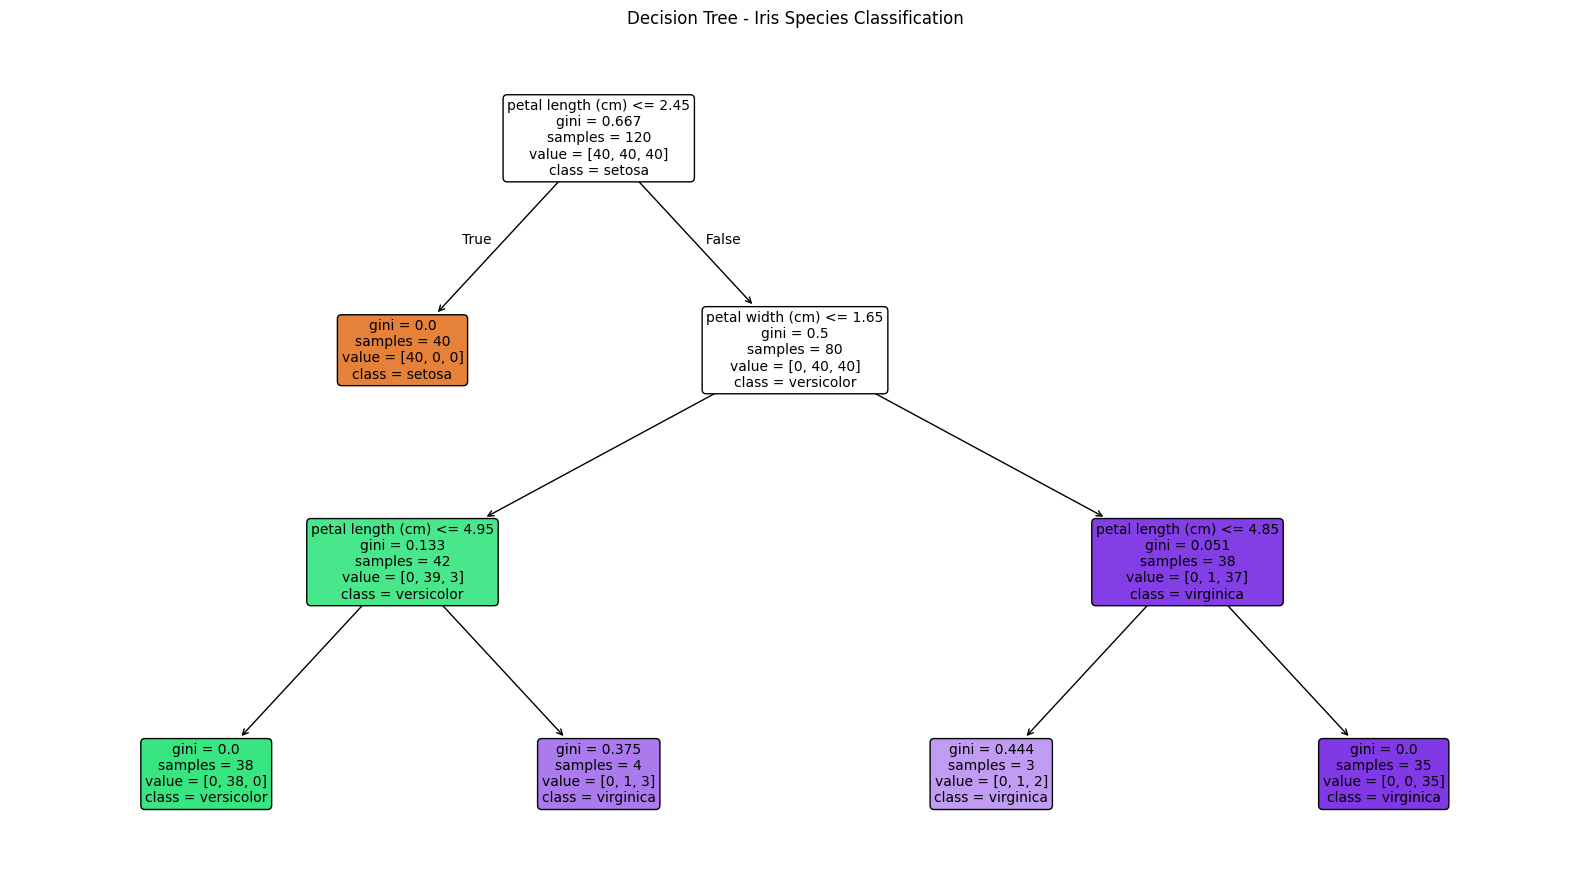

In [7]:
# 5. Visualize the decision tree

plt.figure(figsize=(16, 9))
plot_tree(model, feature_names=feature_cols, class_names=model.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree - Iris Species Classification")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150)
print("\nSaved plots -> confusion_matrix.png, decision_tree.png")
plt.show()